In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from plot_eos_inference import load_posterior, plot_mr, plot_ml, plot_pressure, plot_pop, corner_plot, get_quantiles, r14_confidence_interval, mtov_confidence_interval, plot_mr_nofill, plot_pop_nofill, plot_cosmo

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }
fontsize=14

def pressure_confidence_interval(posterior):
    x = np.geomspace(0.5, 10, 100) # densities 
    x, quantiles, _ = get_quantiles(x, posterior["densities_EOS"] / 0.16, posterior["pressures_EOS"], posterior["weights"])

    lower = np.interp(3, x, quantiles[:, 0])
    median = np.interp(3, x, quantiles[:, 2])
    upper = np.interp(3, x, quantiles[:, 4])
    plus = upper-median
    minus = median-lower

    return f"{{{median:.0f}}}^{{+{plus:.0f}}}_{{-{minus:.0f}}}"

def confidence_interval(samples, weights):

    lower, median, upper = np.quantile(samples, [0.025, 0.5, 0.975], weights=weights, method="inverted_cdf")
    minus = median - lower
    plus = upper - median

    return f"{{{median:.2f}}}_{{-{minus:.2f}}}^{{+{plus:.2f}}}"

## narrow ETL

In [23]:
directory = Path("../narrow_ETL")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5") # remove 6937, 6931 for better EOS fit ?
posterior_alt = load_posterior(directory / "cosmo_inference_withoutem" / "outdir" / "results.h5")
#posterior_alt = load_posterior(Path("/work/koehn1/mma_analyses/eos_inference/narrow_ETL/inference_eos/mm/outdir_mm/results.h5"))

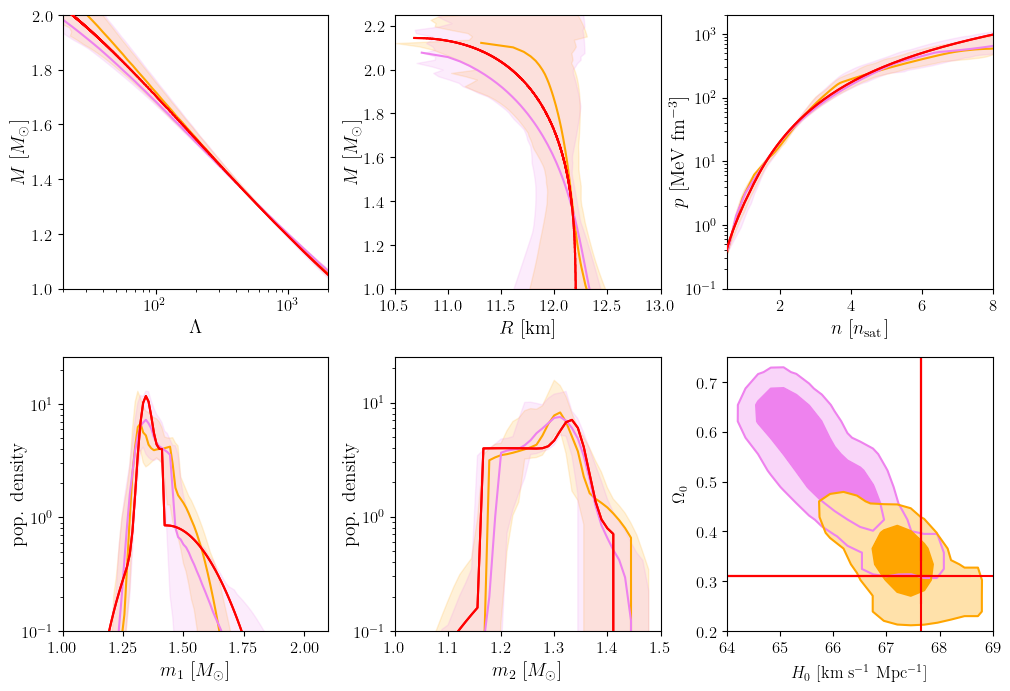

In [29]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
fig.subplots_adjust(wspace=0.25, hspace=0.25)



plot_ml(ax[0,0], posterior, color="orange")
plot_ml(ax[0,0], posterior_alt, color="violet")

plot_mr(ax[0,1], posterior, color="orange", plot_bestfit=True,)
plot_mr(ax[0,1], posterior_alt, color="violet",)

plot_pressure(ax[0,2], posterior, color="orange",)
plot_pressure(ax[0,2], posterior_alt, color="violet")



plot_pop(ax[1,:2], posterior, color="orange")
plot_pop(ax[1,:2], posterior_alt, color="violet")

ax[1, 1].set_xlim((1.0, 1.5))


plot_cosmo(ax[1, 2], posterior_alt, color="violet", labelpad=6)
plot_cosmo(ax[1, 2], posterior, color="orange", labelpad=6)
ax[1, 2].set_ylim((0.2, 0.75))
ax[1, 2].set_xlim((64, 69))
ax[1, 2].vlines([67.66], *ax[1,2].get_ylim(), color="red")
ax[1, 2].hlines([0.30966], *ax[1,2].get_xlim(), color="red")


fig.savefig('../../figures/cosmo_inference_narrow_ETL.pdf', dpi=250, bbox_inches="tight")


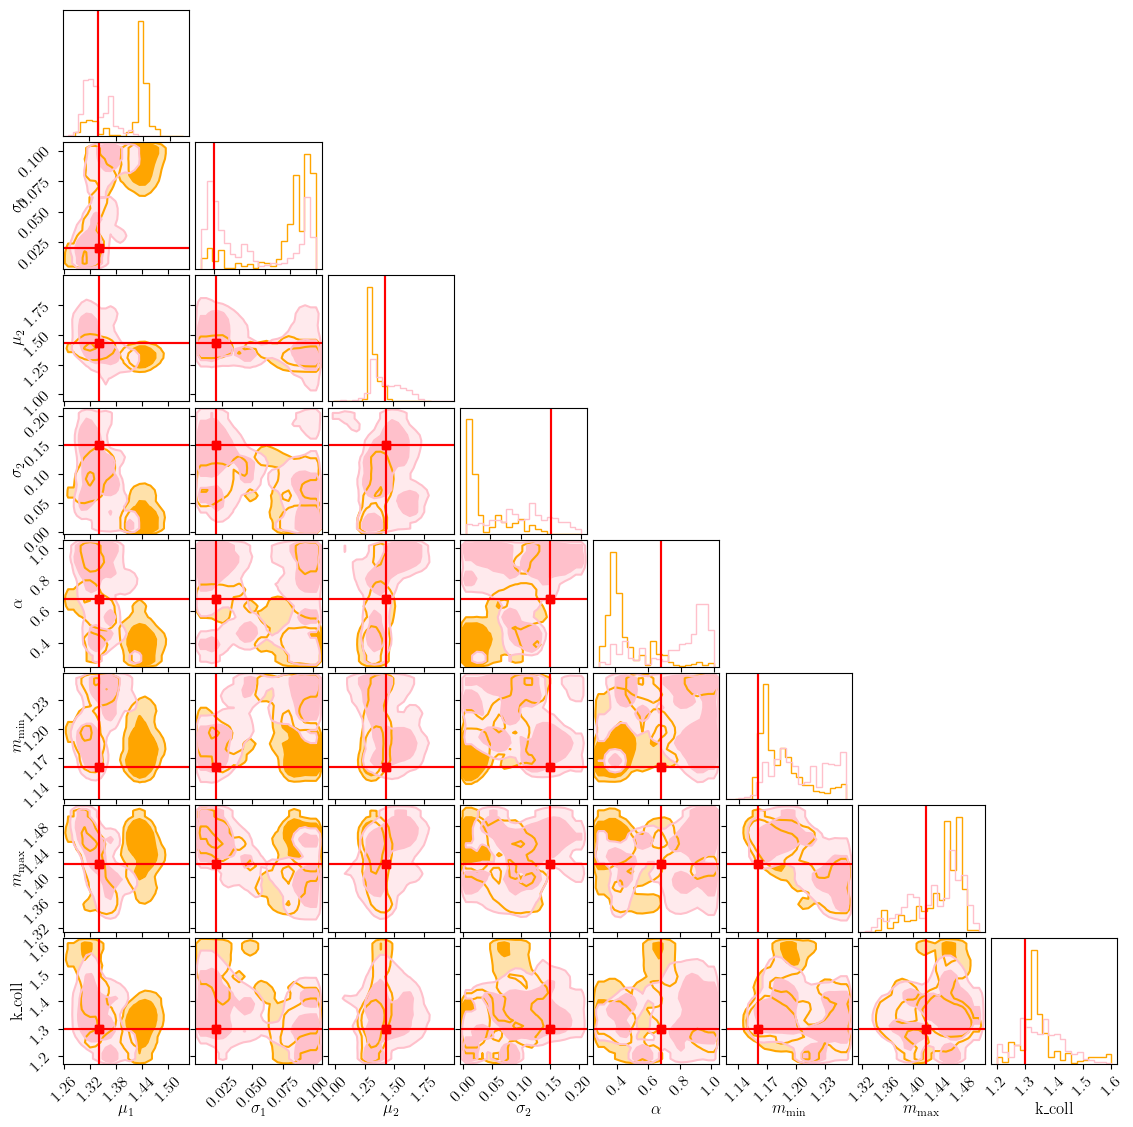

In [12]:
fig = corner_plot(posterior, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max", "k_coll"], color='orange')
fig = corner_plot(posterior_alt, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max", "k_coll"], fig=fig, color='pink')

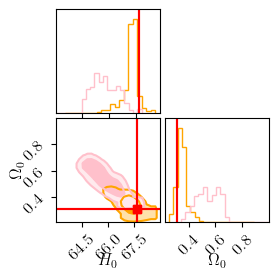

In [6]:
fig = corner_plot(posterior, ["H0", "Omega0"], color="orange")
fig = corner_plot(posterior_alt, ["H0", "Omega0"], fig=fig, color="pink")

In [13]:
print(r14_confidence_interval(posterior))
print(r14_confidence_interval(posterior_alt))

{12.16}^{+0.09}_{-0.23}
{11.98}^{+0.27}_{-0.23}


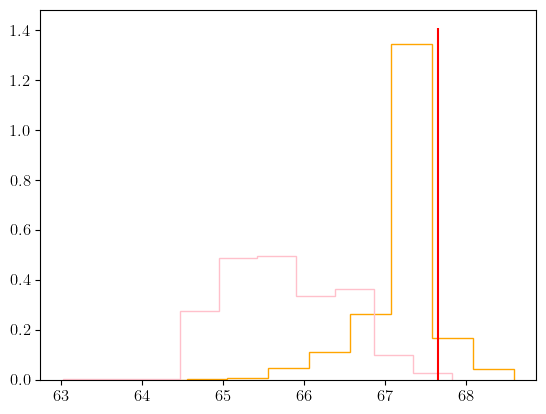

In [7]:
plt.hist(posterior["H0"], weights=posterior["weights"], histtype="step", density=True, color="orange")
plt.hist(posterior_alt["H0"], weights=posterior_alt["weights"], histtype="step", density=True, color="pink")
plt.vlines([67.66], *plt.gca().get_ylim(), color="red")

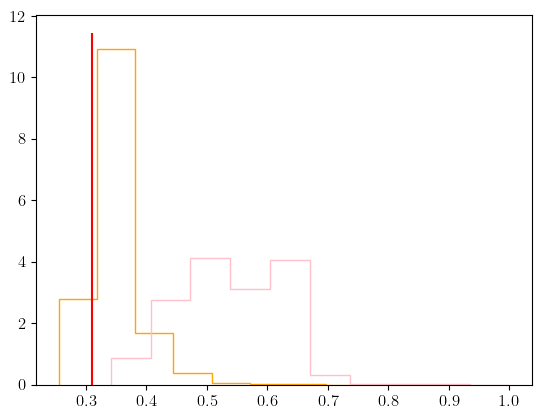

In [8]:
plt.hist(posterior["Omega0"], weights=posterior["weights"], histtype="step", density=True, color="orange")
plt.hist(posterior_alt["Omega0"], weights=posterior_alt["weights"], histtype="step", density=True, color="pink")
plt.vlines([0.30996], *plt.gca().get_ylim(), color="red")

In [9]:
confidence_interval(posterior["H0"], posterior["weights"])

'{67.30}_{-1.31}^{+0.73}'

In [10]:
confidence_interval(posterior["Omega0"], posterior["weights"])

'{0.34}_{-0.08}^{+0.10}'

(284.1412986918468, 497.04925105666194)

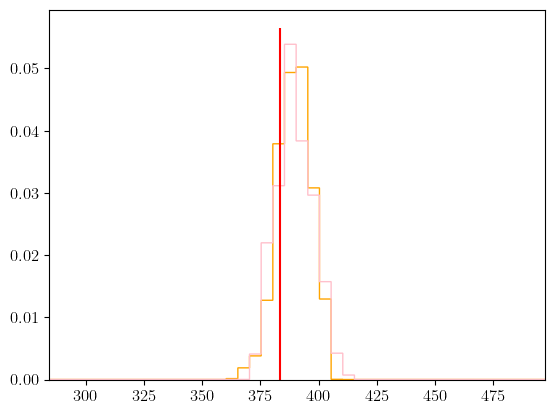

In [21]:
mx = 1.4

l14 = np.array([np.interp(mx, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])
l14_alt = np.array([np.interp(mx, posterior_alt["masses_EOS"][j], posterior_alt["lambdas_EOS"][j]) for j in range(7000)])
r14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])
mtov = np.array([ posterior["masses_EOS"][j].max() for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])
plt.hist(l14_alt, color="pink", density=True, histtype="step", bins=bins, weights=posterior["weights"])

plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, 1.2*l14.max()))

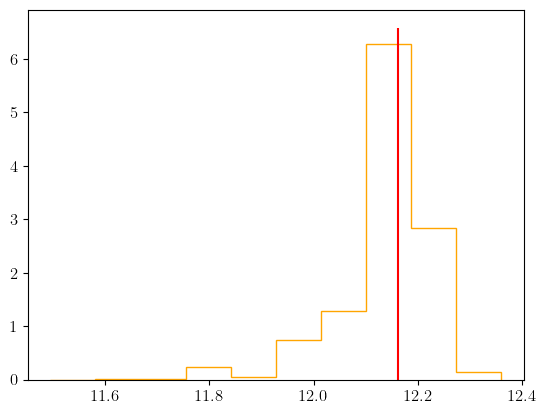

In [12]:
plt.hist(r14, weights=posterior["weights"], color='orange', density=True, histtype="step")
plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")

# Other cosmo plots

In [31]:
narrow_ETL = load_posterior(Path("../narrow_ETL") / "cosmo_inference" / "outdir" / "results.h5")
wide_ETL = load_posterior(Path("../wide_ETL") / "cosmo_inference" / "outdir" / "results.h5")
narrow_ETT = load_posterior(Path("../narrow_ETT") / "cosmo_inference" / "outdir" / "results.h5")
wide_ETT = load_posterior(Path("../wide_ETT") / "cosmo_inference" / "outdir" / "results.h5")

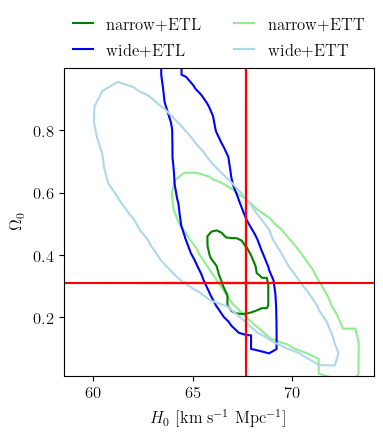

In [34]:
fig, ax = plt.subplots(1,1, figsize=(4,4))

plot_cosmo(ax, narrow_ETT, color="lightgreen", fill_contours=False, levels=[0.95], linestyle="solid")
plot_cosmo(ax, narrow_ETL, color="green", fill_contours=False, levels=[0.95],)
plot_cosmo(ax, wide_ETL, color="blue", fill_contours=False, levels=[0.95],)
plot_cosmo(ax, wide_ETT, color="lightblue", fill_contours=False, levels=[0.95], linestyle="solid")


lc1 = plt.plot([], [], color="green")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="lightgreen")[0]
lc4 = plt.plot([], [], color="lightblue")[0]
ax.legend(
    [lc1, lc2, lc3, lc4], 
    ["narrow+ETL", "wide+ETL", "narrow+ETT", "wide+ETT"], 
    handlelength=1.2, handleheight=1.2, fontsize=12,
    bbox_to_anchor=[0.5, 0.98], loc='lower center', frameon=False, ncol=2
)

fig.savefig("../../figures/cosmo_inference_all.pdf", dpi=250, bbox_inches="tight")

## wide ETL

In [2]:
directory = Path("../wide_ETL")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")

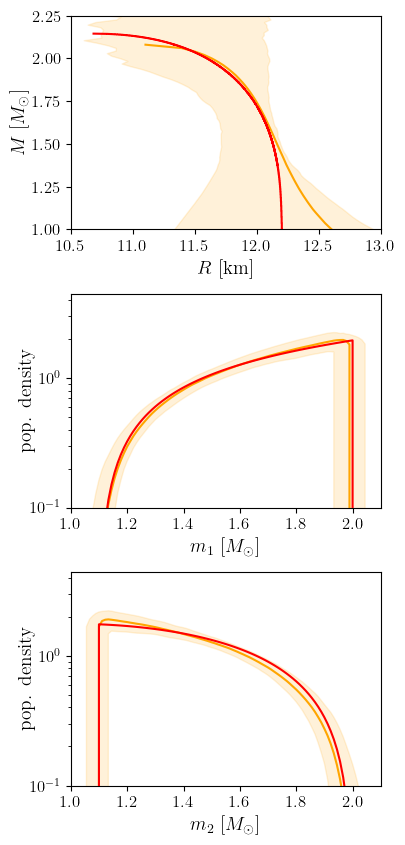

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior, color="orange")

plot_pop(ax[1:], posterior, color="orange")

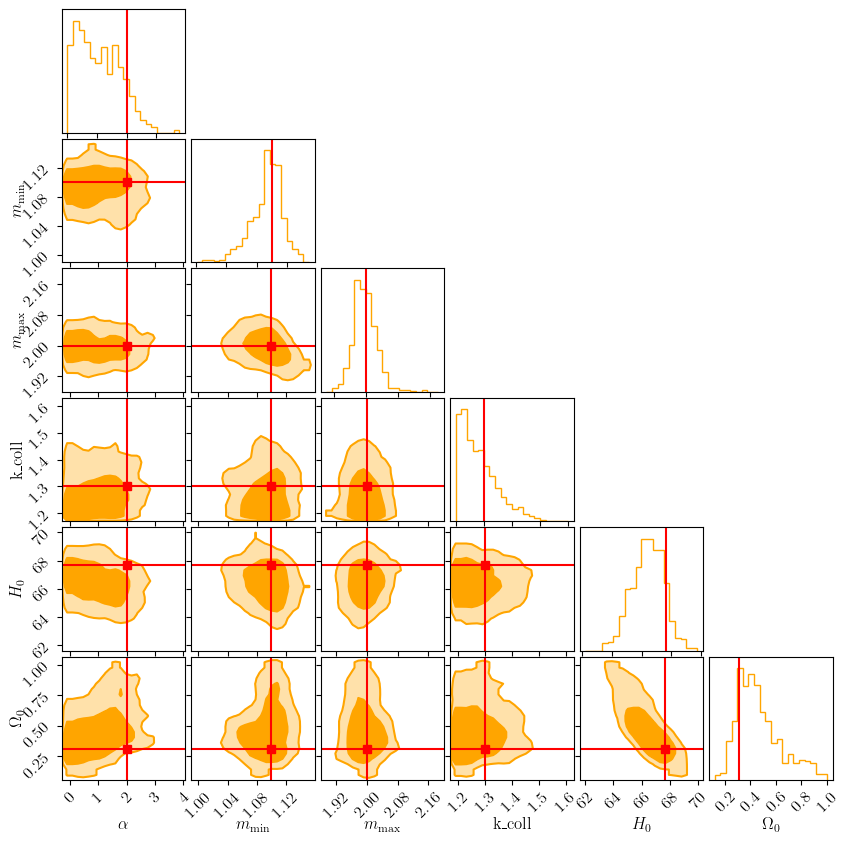

In [4]:
fig = corner_plot(posterior, ["alpha", "m_min", "m_max", "k_coll", "H0", "Omega0"], color="orange")

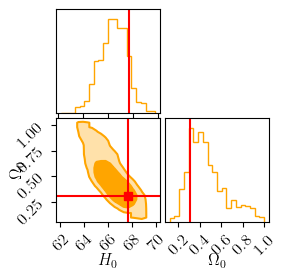

In [5]:
fig = corner_plot(posterior, ["H0", "Omega0"], color='orange')

In [23]:
print(confidence_interval(posterior["H0"], weights=posterior["weights"]))
print(confidence_interval(posterior["Omega0"], weights=posterior["weights"]))

{66.41}_{-1.86}^{+2.05}
{0.45}_{-0.23}^{+0.27}


(285.43286859571396, 651.1091986459619)

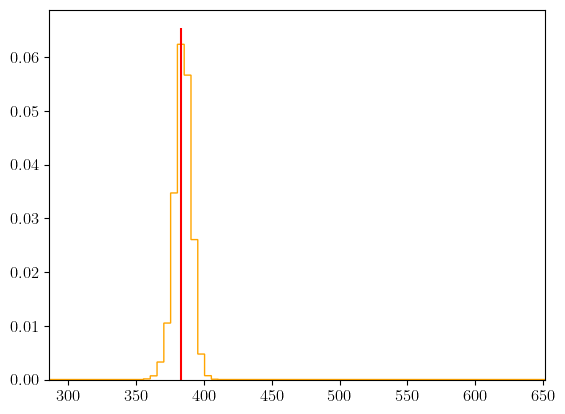

In [35]:
mx = 1.4

l14 = np.array([np.interp(mx, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])
r14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])
mtov = np.array([ posterior["masses_EOS"][j].max() for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, l14.max()*1.6))

# Narrow ETT

In [10]:
directory = Path("../narrow_ETT")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")
posterior_noem = load_posterior(directory / "cosmo_inference_withoutem" / "outdir" / "results.h5")

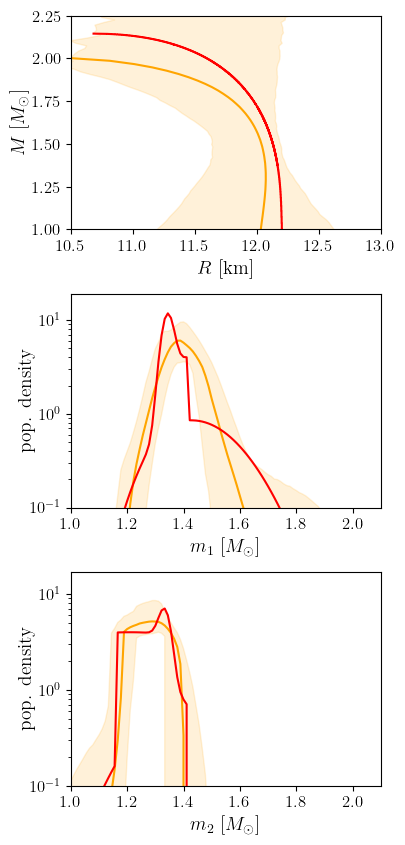

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)



plot_mr(ax[0], posterior, color="orange")
# plot_mr(ax[0], posterior_noem, color="pink")

plot_pop(ax[1:], posterior, color="orange")
# plot_pop(ax[1:], posterior_noem, color="pink")

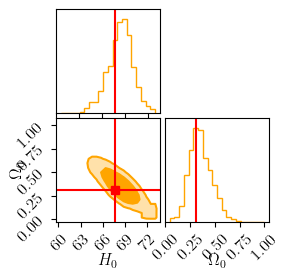

In [ ]:
fig = corner_plot(posterior, ["H0", "Omega0"], color='orange')

In [25]:
for key in ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"]:
    print(key, np.corrcoef(posterior["H0"], posterior[key])[0,1])

print("R14", np.corrcoef(r14, posterior["H0"])[0,1])

mu_1 -0.25034400446419275
sigma_1 -0.14270656368424256
mu_2 -0.18637331672284482
sigma_2 0.013447392158977774
alpha 0.14686398223804428
m_min 0.037433336741493003
m_max 0.38359115734372995
R14 0.034787845489167954


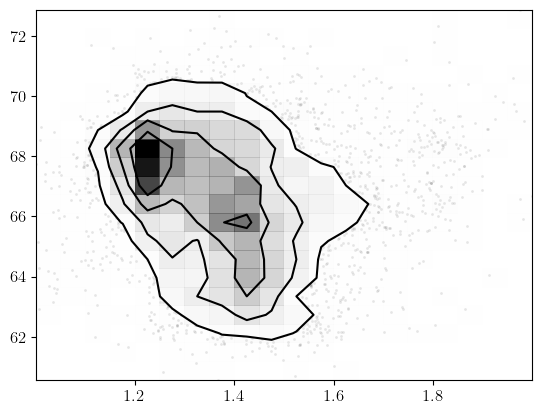

In [28]:
import corner

corner.hist2d(posterior["mu_2"], posterior["H0"])

(249.3896658682529, 519.9612827425022)

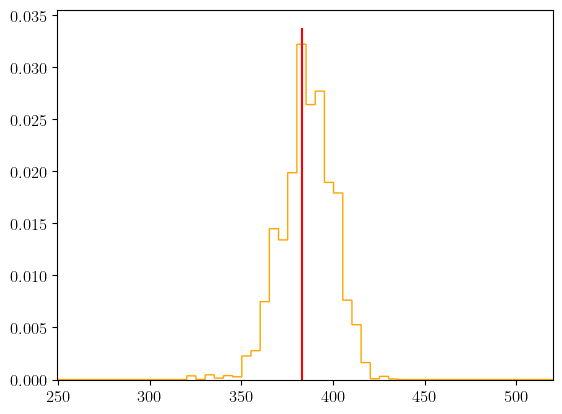

In [19]:
l14 = np.array([np.interp(1.4, posterior["masses_EOS"][j], posterior["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(1.4, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14.min()*0.8, l14.max()*1.2))

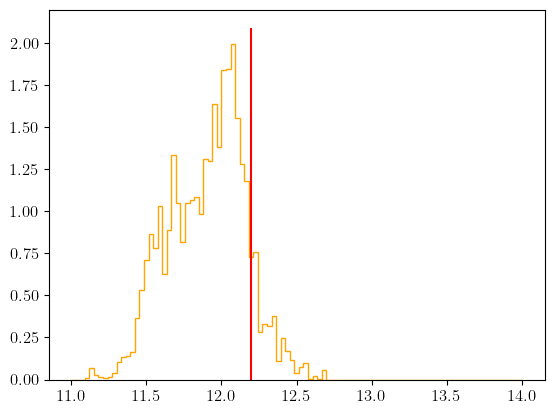

In [17]:
r14 = np.array([np.interp(1.2, posterior["masses_EOS"][j], posterior["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(11, 14, 100)
plt.hist(r14, color="orange", density=True, histtype="step", bins=bins, weights=posterior["weights"])


plt.vlines([np.interp(1.2, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")


In [ ]:
print(confidence_interval(posterior["H0"], posterior["weights"]))

## wide ETT

In [6]:
directory = Path("../wide_ETT")

posterior = load_posterior(directory / "cosmo_inference" / "outdir" / "results.h5")


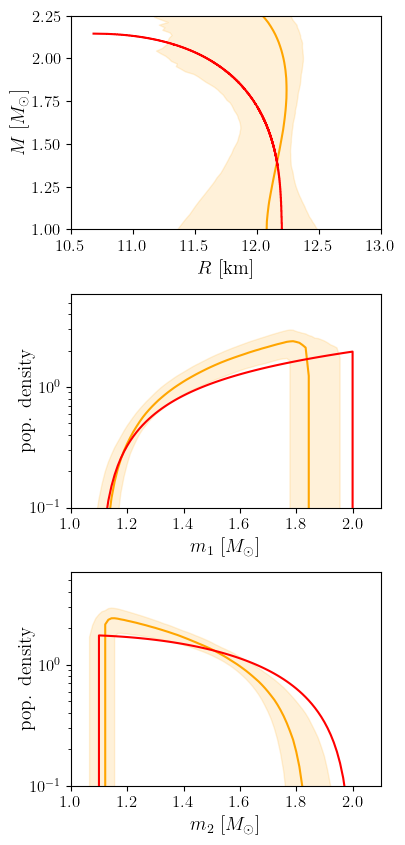

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior, color="orange")

plot_pop(ax[1:], posterior, color="orange")

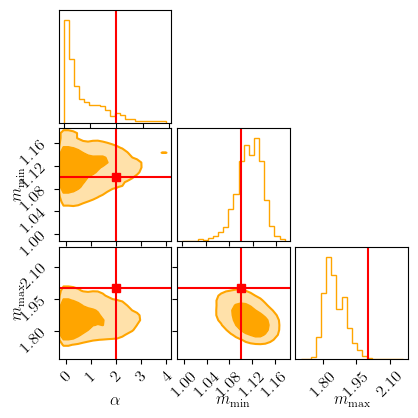

In [8]:
fig = corner_plot(posterior, ["alpha", "m_min", "m_max"], color="orange")


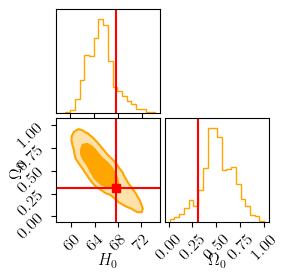

In [9]:
fig = corner_plot(posterior, ["H0", "Omega0"], color='orange')


# Test mass distributions

In [3]:
from jesterTOV.inference.population.populations import massratiopowerlaw_logpdf, MassRatioPowerLaw, recycledbinary_logpdf
import jax


def cred_contour(xx, yy, pdf):

    integrals = np.zeros(400)
    limits = np.linspace(0, pdf.max(), 400)

    for j, limit in enumerate(limits):

        new_pdf = pdf.copy()
        new_pdf[new_pdf<=limit] = 0
        integrals[j] = np.sum(new_pdf * (xx[0,0]-xx[0,1])**2)
    
    return np.interp([0.5], integrals[::-1], limits[::-1])

    

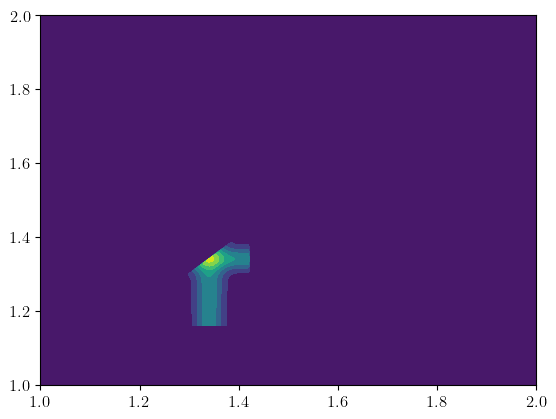

In [4]:


m_arr = np.linspace(1,2, 501)
xx, yy = np.meshgrid(m_arr, m_arr)

pdf = np.exp(recycledbinary_logpdf(xx, yy, dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42)))
#pdf[xx<yy] = 0

plt.contourf(m_arr, m_arr, pdf)

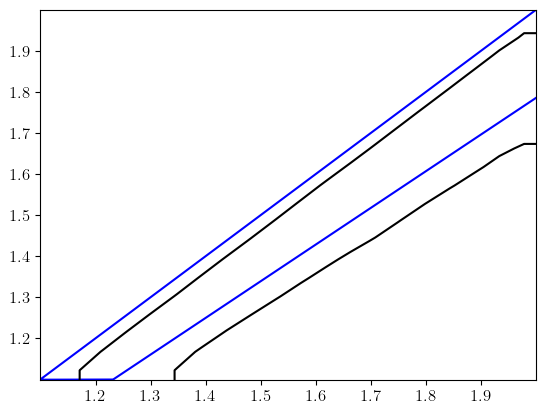

In [9]:
from jesterTOV.inference.population.populations import massratiopowerlaw_logpdf, MassRatioPowerLaw
import jax

m1, m2 = MassRatioPowerLaw(jax.random.key(424), dict(alpha=3, m_min=1.1, m_max=2.0), 600_000)

m_arr = np.linspace(1,2, 701)
xx, yy = np.meshgrid(m_arr, m_arr)

pdf = np.exp(massratiopowerlaw_logpdf(xx, yy, dict(alpha=3, m_min=1.1, m_max=2.0)))
levels = cred_contour(xx, yy, pdf,)

#pdf[xx<yy] = 0

plt.contour(m_arr, m_arr, pdf, levels=levels, colors="blue")
corner.hist2d(m1, m2, levels=[0.5], color="black", plot_density=False, plot_datapoints=False, fill_contours=False, no_fill_contours=True, smooth=True)

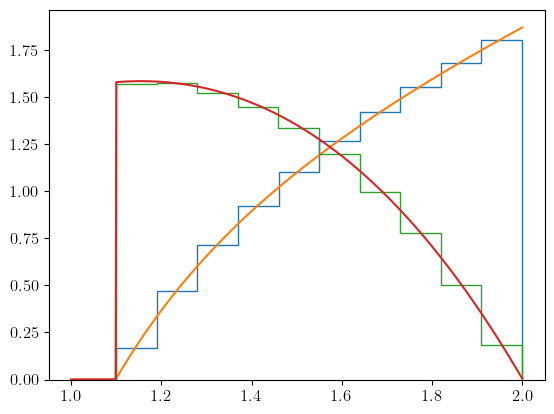

In [10]:
plt.hist(m1, density=True, histtype="step")
plt.plot(m_arr, np.sum(pdf, axis=0) * (m_arr[1] - m_arr[0]))

plt.hist(m2, density=True, histtype="step")
plt.plot(m_arr, np.sum(pdf, axis=1) * (m_arr[1] - m_arr[0]))

(array([0.65281688, 2.61126752, 3.91690127, 2.61126752, 0.65281688,
        2.61126752, 4.56971815, 1.30563376, 0.65281688, 3.91690127]),
 array([0.56953493, 0.61208557, 0.65463621, 0.69718686, 0.7397375 ,
        0.78228814, 0.82483878, 0.86738943, 0.90994007, 0.95249071,
        0.99504135]),
 [<matplotlib.patches.Polygon at 0x7f0fe068e410>])

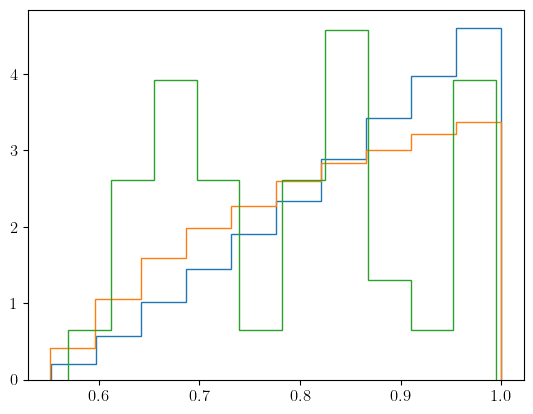

In [11]:
m1, m2 = MassRatioPowerLaw(jax.random.key(42), dict(alpha=2.0, m_min=1.1, m_max=2.0), 100_000)
plt.hist(m2/m1, histtype="step", density=True)

m1, m2 = MassRatioPowerLaw(jax.random.key(42), dict(alpha=0.0, m_min=1.1, m_max=2.0), 100_000)
plt.hist(m2/m1, histtype="step", density=True)

events = pd.read_csv("../../eos_inference/wide_ETL/events.dat", sep=" ")
plt.hist(events["mass_2"] / events["mass_1"], histtype="step", density=True)